In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as ex

In [5]:
df = pd.read_csv('/content/monthly_milk_production.csv', parse_dates=True , index_col='Date')
df.index.freq = 'MS'
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [10]:
df.dtypes

,0
Production,int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [13]:
ex.line(df, x=df.index, y='Production')

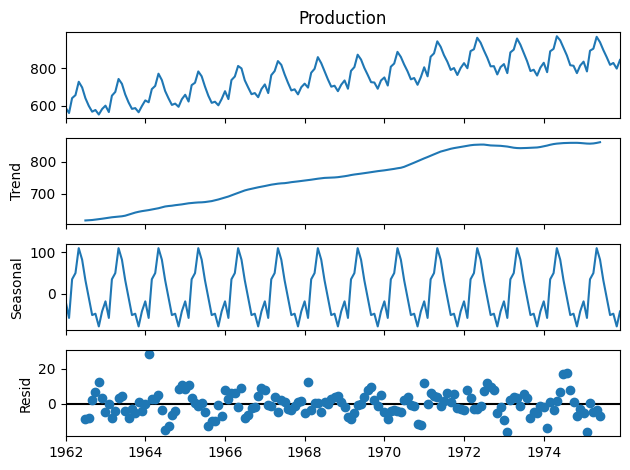

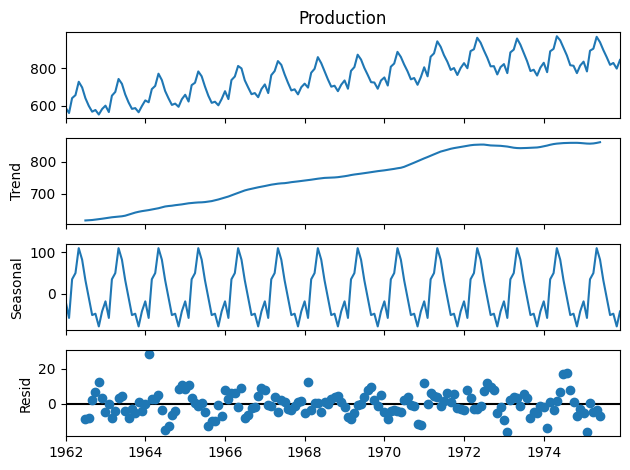

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['Production'])
decompose.plot()

In [15]:
len(df)

168

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train = df[:-156]
test = df[-156:]

scaled_trian = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

In [24]:
scaled_trian

array([[0.20689655],
       [0.04597701],
       [0.5       ],
       [0.59195402],
       [1.        ],
       [0.82758621],
       [0.5       ],
       [0.26436782],
       [0.0862069 ],
       [0.13793103],
       [0.        ],
       [0.16666667]])

In [27]:
import tensorflow as tf
from tensorflow import keras

In [30]:
generator = keras.preprocessing.sequence.TimeseriesGenerator(
    scaled_trian,
    scaled_trian,
    length=3,
    batch_size=1
)

In [31]:
X,y = generator[0]

X , y

(array([[[0.20689655],
         [0.04597701],
         [0.5       ]]]),
 array([[0.59195402]]))

In [36]:
generator = keras.preprocessing.sequence.TimeseriesGenerator(
    scaled_trian,
    scaled_trian,
    length=11,
    batch_size=1
)

In [37]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM

In [38]:
model = Sequential()

model.add(LSTM(100,activation='relu',input_shape=(3,1)))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [39]:
model.summary(      )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.fit(generator, epochs=20)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0243
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0185
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0135
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0092
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0055
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0027
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 8.8206e-04
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 4.0582e-05
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.6624e-04
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0013
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0023
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0028
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0026
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0021
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0014
Epoch 16/20
1/1 ━━━━━━━━

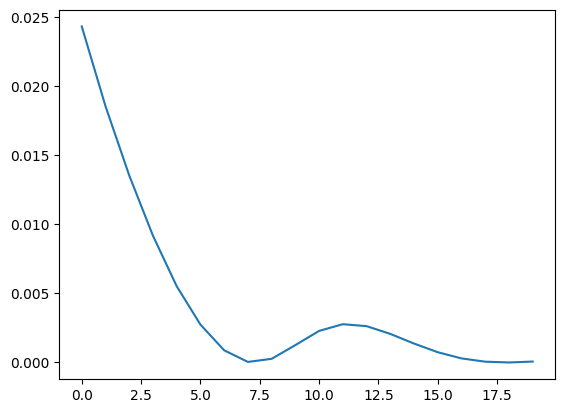

In [42]:
loss_per_epoch = model.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)